In [3]:
!pip install pyspark
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql.functions import avg, abs, count, col, round, mean, coalesce, when, isnull
from functools import reduce
from pyspark.sql.types import *
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.clustering import KMeans, BisectingKMeans, GaussianMixture
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.feature import StandardScaler
from pyspark.ml.feature import PCA
from pyspark.ml.classification import (
    LogisticRegression,
    RandomForestClassifier,
    GBTClassifier
)

import time

In [4]:
spark = SparkSession.builder.appName("Diabetes").getOrCreate()
df = spark.read.csv('diabetes.csv', header=True, inferSchema=True)
df.printSchema()
df.show()


df = df.drop('Diabetes_012')

root
 |-- Diabetes_012: double (nullable = true)
 |-- HighBP: double (nullable = true)
 |-- HighChol: double (nullable = true)
 |-- CholCheck: double (nullable = true)
 |-- BMI: double (nullable = true)
 |-- Smoker: double (nullable = true)
 |-- Stroke: double (nullable = true)
 |-- HeartDiseaseorAttack: double (nullable = true)
 |-- PhysActivity: double (nullable = true)
 |-- Fruits: double (nullable = true)
 |-- Veggies: double (nullable = true)
 |-- HvyAlcoholConsump: double (nullable = true)
 |-- AnyHealthcare: double (nullable = true)
 |-- NoDocbcCost: double (nullable = true)
 |-- GenHlth: double (nullable = true)
 |-- MentHlth: double (nullable = true)
 |-- PhysHlth: double (nullable = true)
 |-- DiffWalk: double (nullable = true)
 |-- Sex: double (nullable = true)
 |-- Age: double (nullable = true)
 |-- Education: double (nullable = true)
 |-- Income: double (nullable = true)

+------------+------+--------+---------+----+------+------+--------------------+------------+------+--

In [5]:
df = df.na.drop()
feature_columns = df.columns

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="raw_features"
)


scaler = StandardScaler(
    inputCol="raw_features",
    outputCol="features"
)
pipeline = Pipeline(
    stages=[
        assembler,
        scaler
    ]
)

pipeline_model = pipeline.fit(df)

data = pipeline_model.transform(df)

Best KMeans k = 2


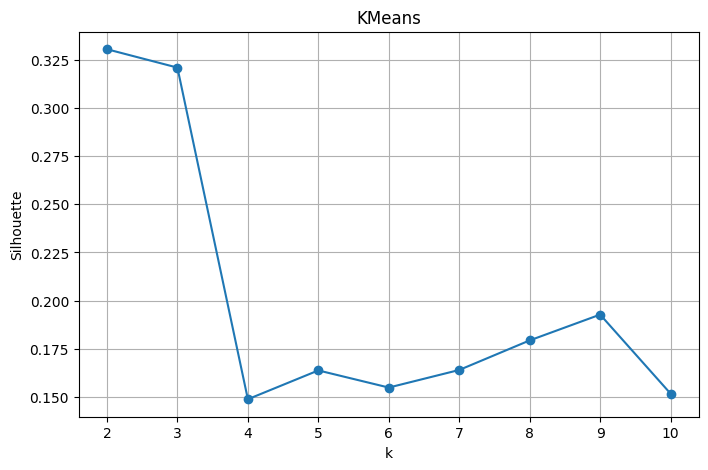

In [7]:

kmeans_scores = []

for k in range(2, 11):

    model = KMeans(
        k=k,
        seed=42,
        maxIter=100,
        featuresCol="features"
    ).fit(data)

    pred = model.transform(data)

    score = ClusteringEvaluator().evaluate(pred)

    kmeans_scores.append(score)

best_k_kmeans = np.argmax(kmeans_scores) + 2

print("Best KMeans k =", best_k_kmeans)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), kmeans_scores, marker='o')
plt.title("KMeans")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.grid()
plt.show()

Best BisectingKMeans k = 2


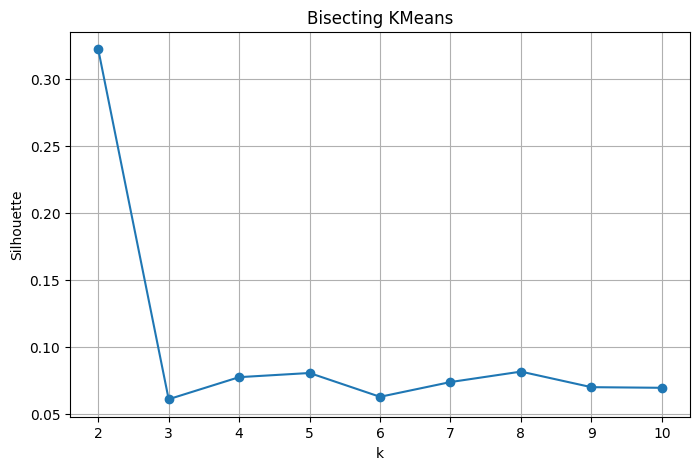

In [ ]:

bkm_scores = []

for k in range(2, 11):

    model = BisectingKMeans(
        k=k,
        seed=42,
        featuresCol="features"
    ).fit(data)

    pred = model.transform(data)

    score = ClusteringEvaluator().evaluate(pred)

    bkm_scores.append(score)

best_k_bkm = np.argmax(bkm_scores) + 2

print("Best BisectingKMeans k =", best_k_bkm)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), bkm_scores, marker='o')
plt.title("Bisecting KMeans")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.grid()
plt.show()

k=2, logL=-6780709.84, BIC=13568276.23
k=3, logL=-6411055.44, BIC=12832401.94
k=4, logL=-6015519.95, BIC=12044765.44
k=5, logL=-5853745.91, BIC=11724651.86
k=6, logL=-5719881.89, BIC=11460358.31
k=7, logL=-5510277.47, BIC=11044583.97
k=8, logL=-5556294.80, BIC=11140053.12
k=9, logL=-5494175.16, BIC=11019248.34
k=10, logL=-5267422.82, BIC=10569178.16


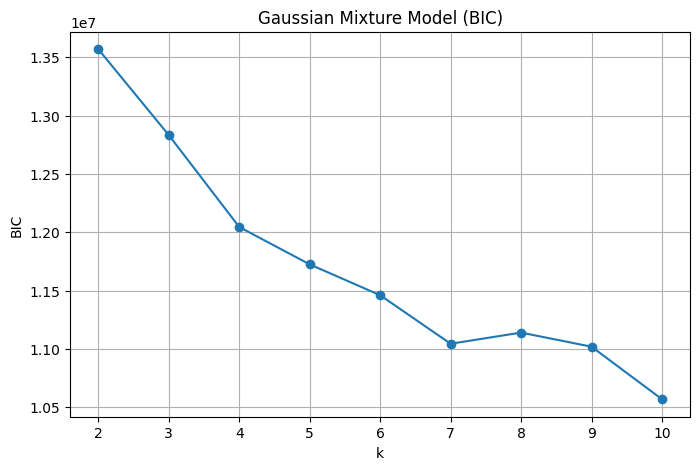

In [ ]:
n = data.count()

d = len(data.select("features").first()[0])
best_bic = float("inf")
best_gmm = None
best_k_gmm = None
bic_scores = []

for k in range(2, 11):

    model = GaussianMixture(
        k=k,
        seed=42,
        maxIter=40,
        featuresCol="features"
    ).fit(data)

    log_likelihood = model.summary.logLikelihood

    p = (
        (k - 1)
        + k * d
        + k * d * (d + 1) / 2
    )

    bic = -2 * log_likelihood + p * np.log(n)

    bic_scores.append(bic)

    if bic < best_bic:
        best_bic = bic
        best_gmm = model
        best_k_gmm = k

    print(
        f"k={k}, "
        f"logL={log_likelihood:.2f}, "
        f"BIC={bic:.2f}"
    )

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    bic_scores,
    marker="o"
)

plt.xlabel("k")
plt.ylabel("BIC")
plt.title("Gaussian Mixture Model (BIC)")
plt.grid()

plt.show()

In [ ]:
pred_gmm = best_gmm.transform(data)

gmm_silhouette = ClusteringEvaluator().evaluate(
    pred_gmm
)

In [ ]:
print("KMeans best score:", max(kmeans_scores))
print("BisectingKMeans best score:", max(bkm_scores))
print("GMM best score:", gmm_silhouette)

KMeans best score: 0.3223241847294698
BisectingKMeans best score: 0.3220840982382706
GMM best score: 0.2492607319199597


In [8]:
best_model = KMeans(
    k=best_k_kmeans,
    seed=42,
    featuresCol="features"
).fit(data)

clustered = best_model.transform(data)

clustered.select("prediction").show()

+----------+
|prediction|
+----------+
|         1|
|         0|
|         1|
|         0|
|         0|
|         0|
|         1|
|         1|
|         1|
|         0|
|         0|
|         1|
|         0|
|         1|
|         1|
|         0|
|         0|
|         0|
|         0|
|         0|
+----------+
only showing top 20 rows


In [9]:
classification_df = clustered.withColumnRenamed(
    "prediction",
    "label"
)

In [10]:
classification_df = classification_df.select(
    "features",
    "label"
)

In [11]:
train_data, test_data = classification_df.randomSplit(
    [0.7, 0.3],
    seed=42
)

In [12]:
cluster_stats = clustered.groupBy(
    "prediction"
).mean()

cluster_stats.show(truncate=False)

+----------+-------------------+------------------+------------------+------------------+-------------------+--------------------+-------------------------+------------------+------------------+------------------+----------------------+------------------+--------------------+-----------------+------------------+------------------+--------------------+-------------------+------------------+-----------------+-----------------+---------------+
|prediction|avg(HighBP)        |avg(HighChol)     |avg(CholCheck)    |avg(BMI)          |avg(Smoker)        |avg(Stroke)         |avg(HeartDiseaseorAttack)|avg(PhysActivity) |avg(Fruits)       |avg(Veggies)      |avg(HvyAlcoholConsump)|avg(AnyHealthcare)|avg(NoDocbcCost)    |avg(GenHlth)     |avg(MentHlth)     |avg(PhysHlth)     |avg(DiffWalk)       |avg(Sex)           |avg(Age)          |avg(Education)   |avg(Income)      |avg(prediction)|
+----------+-------------------+------------------+------------------+------------------+-------------------+-

In [ ]:
categorical_cols = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "NoDocbcCost",
    "DiffWalk",
    "Sex",
    "Education",
    "Income"
]

In [ ]:
for c in categorical_cols:

    print(f"\n=== {c} ===")

    clustered.groupBy(
        "prediction",
        c
    ).count() \
     .orderBy(
         "prediction",
         col("count").desc()
     ) \
     .show()


=== HighBP ===
+----------+------+------+
|prediction|HighBP| count|
+----------+------+------+
|         0|   0.0|126129|
|         0|   1.0| 60441|
|         1|   1.0| 48388|
|         1|   0.0| 18722|
+----------+------+------+


=== HighChol ===
+----------+--------+------+
|prediction|HighChol| count|
+----------+--------+------+
|         0|     0.0|121266|
|         0|     1.0| 65304|
|         1|     1.0| 42287|
|         1|     0.0| 24823|
+----------+--------+------+


=== CholCheck ===
+----------+---------+------+
|prediction|CholCheck| count|
+----------+---------+------+
|         0|      1.0|178517|
|         0|      0.0|  8053|
|         1|      1.0| 65693|
|         1|      0.0|  1417|
+----------+---------+------+


=== Smoker ===
+----------+------+------+
|prediction|Smoker| count|
+----------+------+------+
|         0|   0.0|114910|
|         0|   1.0| 71660|
|         1|   1.0| 40763|
|         1|   0.0| 26347|
+----------+------+------+


=== Stroke ===
+------

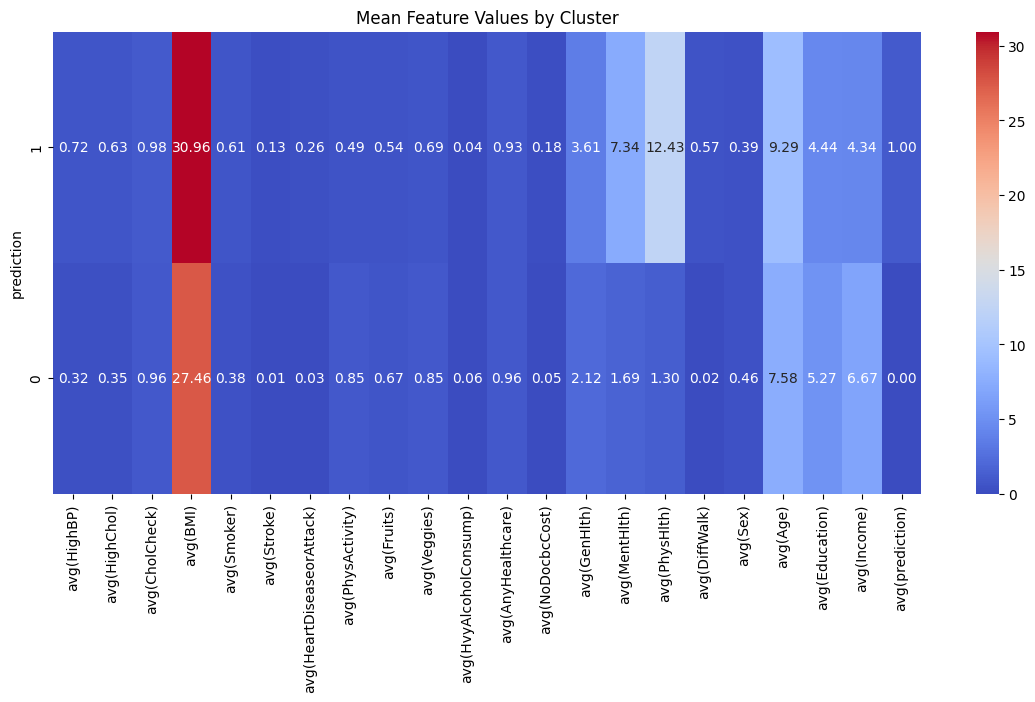

In [20]:
stats_pd = cluster_stats.toPandas()

plt.figure(figsize=(14,6))

sns.heatmap(
    stats_pd.set_index("prediction"),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Mean Feature Values by Cluster")
plt.show()

In [ ]:
pca = PCA(
    k=2,
    inputCol="features",
    outputCol="pca"
)

pca_model = pca.fit(clustered)

pca_df = pca_model.transform(clustered)

In [ ]:
pdf = pca_df.select(
    "prediction",
    "pca"
).toPandas()

pdf["x"] = pdf["pca"].apply(lambda v: float(v[0]))
pdf["y"] = pdf["pca"].apply(lambda v: float(v[1]))

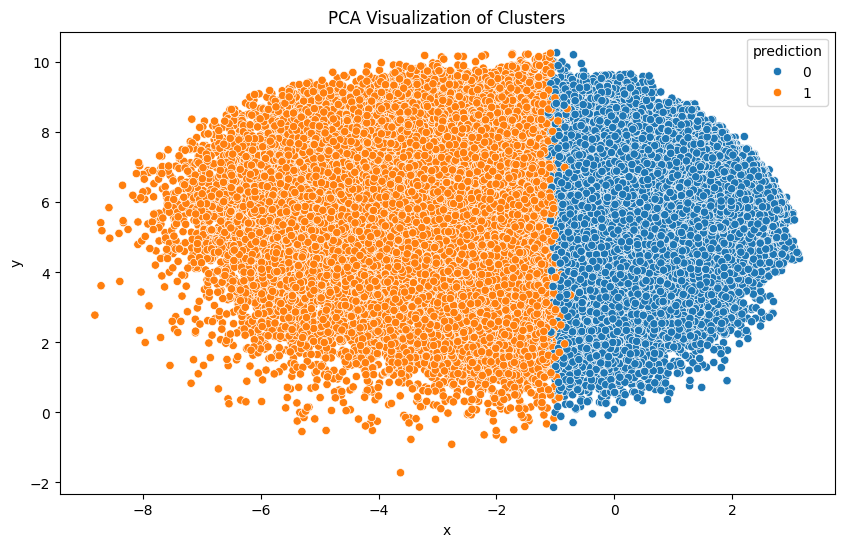

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pdf,
    x="x",
    y="y",
    hue="prediction",
    palette="tab10"
)

plt.title("PCA Visualization of Clusters")
plt.show()

In [ ]:
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label"
)

grid_lr = ParamGridBuilder() \
    .addGrid(lr.regParam, [0.01, 0.1, 1.0]) \
    .build()

cv_lr = CrossValidator(
    estimator=lr,
    estimatorParamMaps=grid_lr,
    evaluator=MulticlassClassificationEvaluator(
        labelCol="label",
        metricName="f1"
    ),
    numFolds=3
)

start = time.time()

model_lr = cv_lr.fit(train_data)

lr_time = time.time() - start

In [ ]:
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label"
)

grid_rf = ParamGridBuilder() \
    .addGrid(rf.maxDepth, [3,5,8]) \
    .addGrid(rf.numTrees, [10,30]) \
    .build()

cv_rf = CrossValidator(
    estimator=rf,
    estimatorParamMaps=grid_rf,
    evaluator=MulticlassClassificationEvaluator(
        labelCol="label",
        metricName="f1"
    ),
    numFolds=3
)

start = time.time()

model_rf = cv_rf.fit(train_data)

rf_time = time.time() - start

In [ ]:
gbt = GBTClassifier(
    featuresCol="features",
    labelCol="label"
)

grid_gbt = ParamGridBuilder() \
    .addGrid(gbt.maxDepth, [3,5,7]) \
    .build()

cv_gbt = CrossValidator(
    estimator=gbt,
    estimatorParamMaps=grid_gbt,
    evaluator=MulticlassClassificationEvaluator(
        labelCol="label",
        metricName="f1"
    ),
    numFolds=3
)

start = time.time()

model_gbt = cv_gbt.fit(train_data)

gbt_time = time.time() - start

In [ ]:
def evaluate_model(model, test_data):

    predictions = model.transform(test_data)

    evaluator = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction"
    )

    accuracy = evaluator.evaluate(
        predictions,
        {evaluator.metricName: "accuracy"}
    )

    precision = evaluator.evaluate(
        predictions,
        {evaluator.metricName: "weightedPrecision"}
    )

    recall = evaluator.evaluate(
        predictions,
        {evaluator.metricName: "weightedRecall"}
    )

    f1 = evaluator.evaluate(
        predictions,
        {evaluator.metricName: "f1"}
    )

    return predictions, accuracy, precision, recall, f1

In [ ]:
pred_lr, acc_lr, prec_lr, rec_lr, f1_lr = evaluate_model(
    model_lr,
    test_data
)

pred_rf, acc_rf, prec_rf, rec_rf, f1_rf = evaluate_model(
    model_rf,
    test_data
)

pred_gbt, acc_gbt, prec_gbt, rec_gbt, f1_gbt = evaluate_model(
    model_gbt,
    test_data
)

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "GBT"
    ],
    "Accuracy": [
        acc_lr,
        acc_rf,
        acc_gbt
    ],
    "F1": [
        f1_lr,
        f1_rf,
        f1_gbt
    ],
    "Precision": [
        prec_lr,
        prec_rf,
        prec_gbt
    ],
    "Recall": [
        rec_lr,
        rec_rf,
        rec_gbt
    ],
    "Training Time (s)": [
        lr_time,
        rf_time,
        gbt_time
    ]
})

print(results)

                 Model  Accuracy        F1  Precision    Recall  \
0  Logistic Regression  0.986350  0.986232   0.986597  0.986350   
1        Random Forest  0.945492  0.944531   0.945342  0.945492   
2                  GBT  0.962229  0.961945   0.962014  0.962229   

   Training Time (s)  
0          67.577368  
1         143.637074  
2         217.656818  


In [ ]:
confusion = pred_lr.groupBy(
    "label",
    "prediction"
).count()

confusion.show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    1|       0.0| 1038|
|    0|       0.0|56016|
|    1|       1.0|19062|
|    0|       1.0|    1|
+-----+----------+-----+

